## Noncompliance and Instruments



In [1]:
import polars as pl
import numpy as np
from plotnine import *

In [2]:
df = pl.read_csv("../data/prime_card.csv")
df.head()

age,income,credit_score,prime_elegible,prime_card,pv,tau,categ
f64,f64,f64,i64,i64,f64,f64,str
37.7,9687.0,822.0,0,0,4913.79,700.0,"""complier"""
46.0,13731.0,190.0,0,0,5637.66,200.0,"""never-taker"""
43.1,2839.0,214.0,1,1,2410.45,700.0,"""complier"""
36.0,1206.0,318.0,1,1,1363.06,700.0,"""complier"""
39.7,4095.0,430.0,0,0,2189.8,700.0,"""complier"""


## Extending Potential Outcomes

In [7]:
import statsmodels.formula.api as smf

# Nota: Convertimos de Polars a pandas porque statsmodels requiere pandas.
m = smf.ols("pv ~ prime_elegible", data=df.to_pandas()).fit()

# Mostramos la tabla de coeficientes del modelo
m.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2498.3618,24.327,102.701,0.000,2450.677,2546.047
prime_elegible,321.3880,34.321,9.364,0.000,254.113,388.663


In [8]:
df.get_column("tau").mean()

413.45

In [16]:
m = smf.ols("pv~prime_card", data=df.to_pandas()).fit()
m.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2534.4947,19.239,131.740,0.000,2496.783,2572.206
prime_card,588.1388,41.676,14.112,0.000,506.446,669.831


## Instrument Identification Assumptions

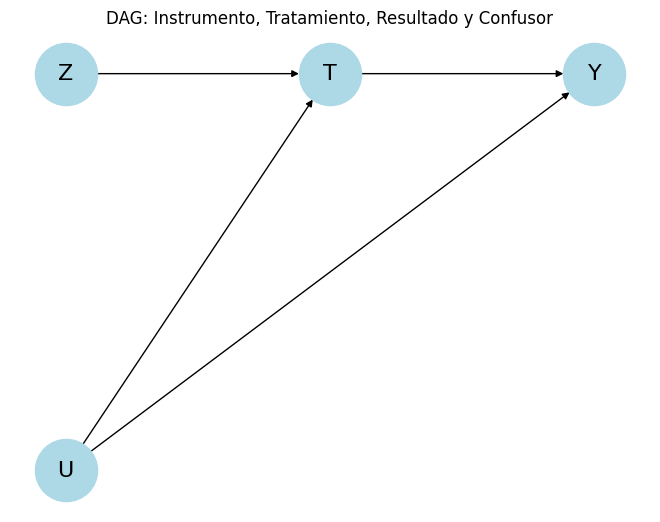

In [17]:
import networkx as nx

import matplotlib.pyplot as plt

# Creamos un grafo dirigido
G = nx.DiGraph()

# Añadimos nodos
G.add_nodes_from(['Z', 'T', 'Y', 'U'])

# Añadimos las aristas según el DAG
G.add_edges_from([
    ('Z', 'T'),   # Z → T
    ('T', 'Y'),   # T → Y
    ('U', 'T'),   # U → T
    ('U', 'Y')    # U → Y
])

# Dibujamos el DAG
pos = {'Z': (0, 1), 'U': (0, 0), 'T': (1, 1), 'Y': (2, 1)}
nx.draw(G, pos, with_labels=True, arrows=True, node_size=2000, node_color='lightblue', font_size=16)
plt.title("DAG: Instrumento, Tratamiento, Resultado y Confusor")
plt.show()

## First Stage

In [18]:
first_stage = smf.ols("prime_card ~ prime_elegible", data=df.to_pandas()).fit()
first_stage.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.369e-15,0.005,2.76e-13,1.000,-0.010,0.010
prime_elegible,0.4242,0.007,60.536,0.000,0.410,0.438


In [19]:
df.group_by("categ").agg(pl.len() / df.shape[0])

categ,len
str,f64
"""complier""",0.4269
"""never-taker""",0.5731


## Reduced Form

In [20]:
red_form = smf.ols("pv ~ prime_elegible", data=df.to_pandas()).fit()
red_form.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2498.3618,24.327,102.701,0.000,2450.677,2546.047
prime_elegible,321.3880,34.321,9.364,0.000,254.113,388.663


In [21]:
late = red_form.params["prime_elegible"] / first_stage.params["prime_elegible"]
late

np.float64(757.6973795343814)

In [22]:
df.group_by("categ").agg(pl.mean("tau"))

categ,tau
str,f64
"""never-taker""",200.0
"""complier""",700.0


## Two-Stage Least Squares

In [25]:
iv_regr = smf.ols(
    "pv ~ prime_card",
    data=df.with_columns(
        prime_card=pl.Series(first_stage.fittedvalues)
    )
).fit().summary().tables[1]
iv_regr

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2498.3618,24.327,102.701,0.000,2450.677,2546.047
prime_card,757.6974,80.914,9.364,0.000,599.091,916.304


In [24]:
first_stage.fittedvalues

0       1.368693e-15
1       1.368693e-15
2       4.241640e-01
3       4.241640e-01
4       1.368693e-15
            ...     
9995    4.241640e-01
9996    1.368693e-15
9997    4.241640e-01
9998    1.368693e-15
9999    4.241640e-01
Length: 10000, dtype: float64